# Drug Response Prediction - Error Analysis

Deep dive into model errors to understand:
- Which drugs are hard to predict
- Which tissues have systematic errors
- Performance across different IC50 ranges
- Error patterns and insights for improvement

## 1. Setup and Load Data

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

import warnings
warnings.filterwarnings('ignore')

# Load the main dataset
df = pd.read_parquet("../data/processed/merged.parquet")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}...")  # Show first 10 columns

# Load test split indices
test_idx = np.load("../data/processed/splits_drug/test_idx.npy")
df_test = df.iloc[test_idx].reset_index(drop=True)
print(f"\nTest set size: {len(df_test)}")

Dataset shape: (562789, 519)
Columns: ['cell_id', 'drug_id', 'drug_name', 'smiles', 'tissue', 'dataset', 'ln_ic50', 'PC1', 'PC2', 'PC3']...

Test set size: 112977


## 2. Load Model Predictions

Load test predictions from all models for comparison.

In [3]:
# Load predictions from different models
y_true = df_test['ln_ic50'].values

# Load MLP baseline predictions
pred_mlp = np.load("../results/mlp_baseline_with_splits/test_preds.npy")

# Load MLP + ChemBERTa predictions
pred_mlp_chemberta = np.load("../results/mlp_chemberta/test_preds.npy")

# Note: MLP + ChemBERTa Tuned doesn't have test_preds.npy saved
# We'll use the two models with available predictions

# Create DataFrame with all predictions
df_test['y_true'] = y_true
df_test['pred_mlp'] = pred_mlp
df_test['pred_mlp_chemberta'] = pred_mlp_chemberta

# Calculate errors
df_test['error_mlp'] = np.abs(y_true - pred_mlp)
df_test['error_mlp_chemberta'] = np.abs(y_true - pred_mlp_chemberta)

print("✓ Predictions loaded successfully!")
print(f"Sample predictions:\n{df_test[['y_true', 'pred_mlp', 'pred_mlp_chemberta']].head()}")

✓ Predictions loaded successfully!
Sample predictions:
     y_true  pred_mlp  pred_mlp_chemberta
0 -1.044427 -1.995587           -2.223446
1  3.638937  1.818314            3.167840
2  1.249498 -3.451234            3.219975
3  2.828407  3.722437            2.188228
4  2.091209  1.793897            2.272572


## 3. Error Distribution Analysis

Analyze overall error distributions across models.

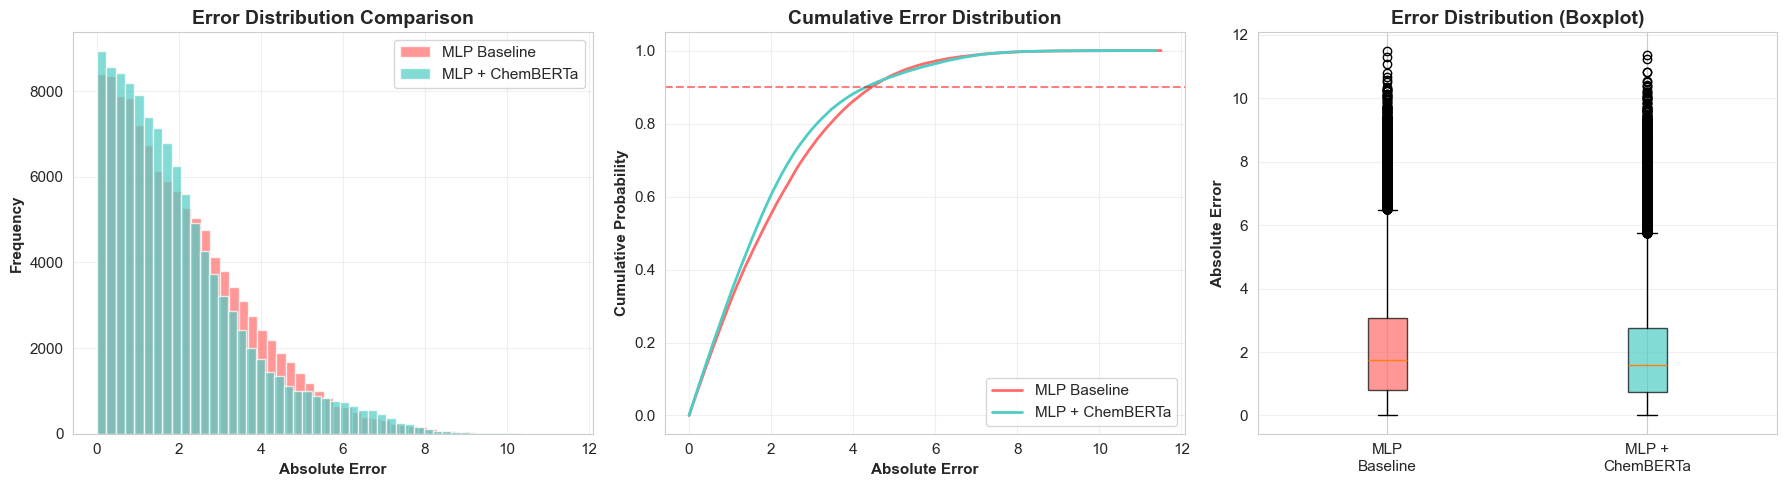


📊 Error Statistics:

MLP Baseline:
  Mean Error: 2.1215
  Median Error: 1.7621
  90th Percentile: 4.4511
  Max Error: 11.5072

MLP + ChemBERTa:
  Mean Error: 1.9922
  Median Error: 1.5921
  90th Percentile: 4.3166
  Max Error: 11.3724


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Error distributions
axes[0].hist(df_test['error_mlp'], bins=50, alpha=0.7, label='MLP Baseline', color='#FF6B6B')
axes[0].hist(df_test['error_mlp_chemberta'], bins=50, alpha=0.7, label='MLP + ChemBERTa', color='#4ECDC4')
axes[0].set_xlabel('Absolute Error', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Error Distribution Comparison', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cumulative error distribution
for model_name, errors, color in [
    ('MLP Baseline', df_test['error_mlp'], '#FF6B6B'),
    ('MLP + ChemBERTa', df_test['error_mlp_chemberta'], '#4ECDC4')
]:
    sorted_errors = np.sort(errors)
    cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
    axes[1].plot(sorted_errors, cumulative, label=model_name, color=color, linewidth=2)

axes[1].set_xlabel('Absolute Error', fontweight='bold')
axes[1].set_ylabel('Cumulative Probability', fontweight='bold')
axes[1].set_title('Cumulative Error Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='90th percentile')

# Box plot comparison
error_data = [df_test['error_mlp'], df_test['error_mlp_chemberta']]
bp = axes[2].boxplot(error_data, labels=['MLP\nBaseline', 'MLP +\nChemBERTa'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_ylabel('Absolute Error', fontweight='bold')
axes[2].set_title('Error Distribution (Boxplot)', fontsize=14, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Error Statistics:")
for model in ['MLP Baseline', 'MLP + ChemBERTa']:
    col = {'MLP Baseline': 'error_mlp', 'MLP + ChemBERTa': 'error_mlp_chemberta'}[model]
    print(f"\n{model}:")
    print(f"  Mean Error: {df_test[col].mean():.4f}")
    print(f"  Median Error: {df_test[col].median():.4f}")
    print(f"  90th Percentile: {df_test[col].quantile(0.9):.4f}")
    print(f"  Max Error: {df_test[col].max():.4f}")

## 4. Per-Drug Error Analysis

Identify which drugs are consistently hard to predict.

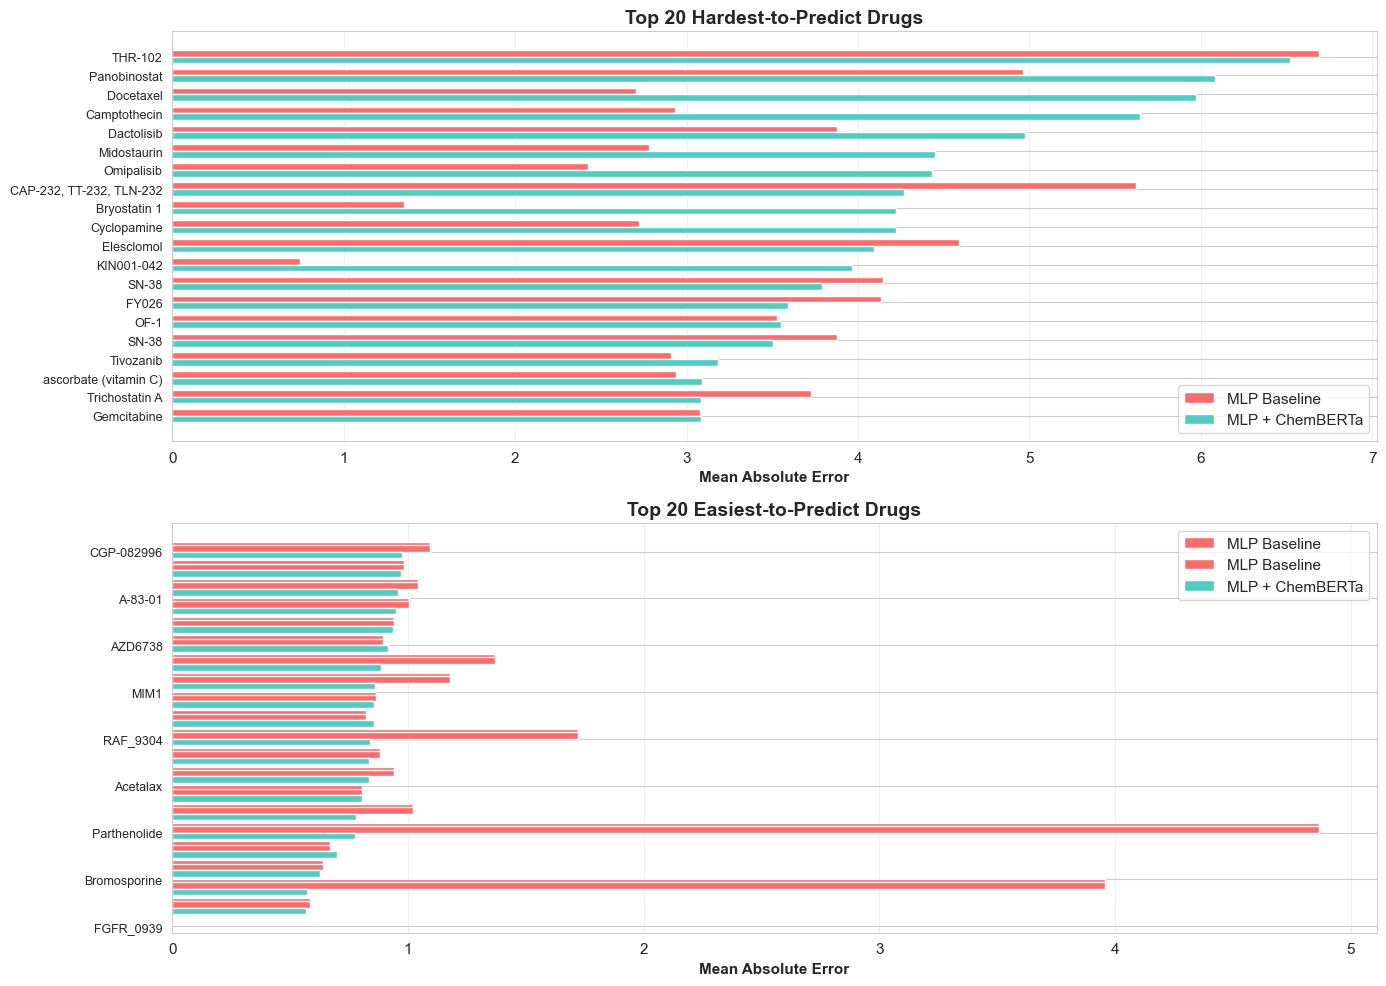


🔴 Top 10 Hardest Drugs:
               drug_name  error_mlp_chemberta  count
                 THR-102             6.521542    728
            Panobinostat             6.080907    877
               Docetaxel             5.971599   1853
            Camptothecin             5.646423    940
              Dactolisib             4.971418   1830
             Midostaurin             4.449470    860
              Omipalisib             4.434255    892
CAP-232, TT-232, TLN-232             4.265921    885
            Bryostatin 1             4.223849    846
             Cyclopamine             4.220230    384

🟢 Top 10 Easiest Drugs:
  drug_name  error_mlp_chemberta  count
 Seliciclib             0.839561    383
 KIN001-244             0.835597    889
 Uprosertib             0.833588    870
    AZD7762             0.806129    904
   XMD11-50             0.777670     95
   XMD15-27             0.776259    892
      VTP-A             0.698291    734
   TTK_3146             0.625089    902
N27922-

In [5]:
# Calculate mean error per drug
drug_errors = df_test.groupby('drug_id').agg({
    'error_mlp': 'mean',
    'error_mlp_chemberta': 'mean',
    'drug_name': 'first'
}).reset_index()

drug_errors['count'] = df_test.groupby('drug_id').size().values

# Sort by ChemBERTa model error
drug_errors_sorted = drug_errors.sort_values('error_mlp_chemberta', ascending=False)

# Top 20 hardest drugs
top_hardest = drug_errors_sorted.head(20)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Hardest drugs
x = np.arange(len(top_hardest))
width = 0.25
width = 0.35
axes[0].barh(x - width/2, top_hardest['error_mlp'], width, label='MLP Baseline', color='#FF6B6B')
axes[0].barh(x + width/2, top_hardest['error_mlp_chemberta'], width, label='MLP + ChemBERTa', color='#4ECDC4')
axes[0].set_yticks(x)
axes[0].set_yticklabels(top_hardest['drug_name'].str[:30], fontsize=9)  # Truncate names
axes[0].set_xlabel('Mean Absolute Error', fontweight='bold')
axes[0].set_title('Top 20 Hardest-to-Predict Drugs', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Easiest drugs
top_easiest = drug_errors_sorted.tail(20)
x = np.arange(len(top_easiest))
axes[1].barh(x - width, top_easiest['error_mlp'], width, label='MLP Baseline', color='#FF6B6B')
width = 0.35
axes[1].barh(x - width/2, top_easiest['error_mlp'], width, label='MLP Baseline', color='#FF6B6B')
axes[1].barh(x + width/2, top_easiest['error_mlp_chemberta'], width, label='MLP + ChemBERTa', color='#4ECDC4')
axes[1].set_yticklabels(top_easiest['drug_name'].str[:30], fontsize=9)
axes[1].set_xlabel('Mean Absolute Error', fontweight='bold')
axes[1].set_title('Top 20 Easiest-to-Predict Drugs', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n🔴 Top 10 Hardest Drugs:")
print(drug_errors_sorted[['drug_name', 'error_mlp_chemberta', 'count']].head(10).to_string(index=False))
print("\n🟢 Top 10 Easiest Drugs:")
print(drug_errors_sorted[['drug_name', 'error_mlp_chemberta', 'count']].tail(10).to_string(index=False))

## 5. Per-Tissue Error Analysis

Analyze systematic errors across different tissue types.

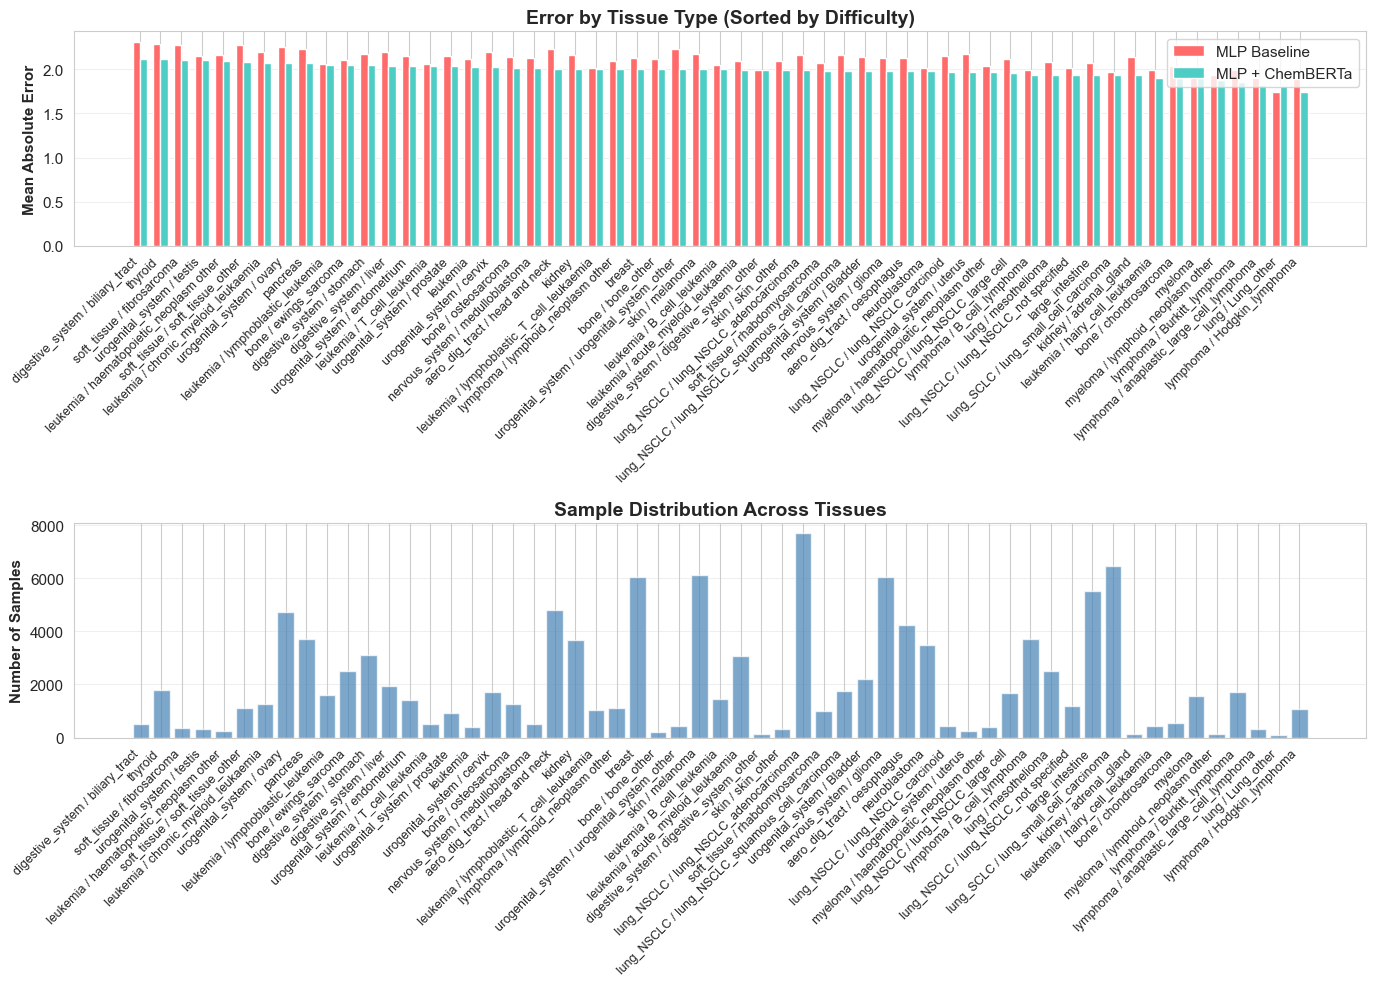


📊 Tissue-specific Performance:
                                         tissue  error_mlp_chemberta  count
               digestive_system / biliary_tract             2.116320    503
                                        thyroid             2.113216   1797
                     soft_tissue / fibrosarcoma             2.103402    362
                     urogenital_system / testis             2.100142    317
       leukemia / haematopoietic_neoplasm other             2.098373    238
                soft_tissue / soft_tissue_other             2.087092   1109
           leukemia / chronic_myeloid_leukaemia             2.076845   1274
                      urogenital_system / ovary             2.076148   4737
                                       pancreas             2.074792   3708
              leukemia / lymphoblastic_leukemia             2.054070   1604
                          bone / ewings_sarcoma             2.049069   2498
                     digestive_system / stomach         

In [6]:
# Check if tissue column exists
if 'tissue' in df_test.columns:
    # Calculate mean error per tissue
    tissue_errors = df_test.groupby('tissue').agg({
        'error_mlp': 'mean',
        'error_mlp_chemberta': 'mean'
    }).reset_index()
    
    tissue_errors['count'] = df_test.groupby('tissue').size().values
    tissue_errors_sorted = tissue_errors.sort_values('error_mlp_chemberta', ascending=False)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # All tissues
    x = np.arange(len(tissue_errors_sorted))
    width = 0.25
    width = 0.35
    axes[0].bar(x - width/2, tissue_errors_sorted['error_mlp'], width, label='MLP Baseline', color='#FF6B6B')
    axes[0].bar(x + width/2, tissue_errors_sorted['error_mlp_chemberta'], width, label='MLP + ChemBERTa', color='#4ECDC4')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(tissue_errors_sorted['tissue'], rotation=45, ha='right', fontsize=9)
    axes[0].set_ylabel('Mean Absolute Error', fontweight='bold')
    axes[0].set_title('Error by Tissue Type (Sorted by Difficulty)', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Sample counts per tissue
    axes[1].bar(np.arange(len(tissue_errors_sorted)), tissue_errors_sorted['count'], color='steelblue', alpha=0.7)
    axes[1].set_xticks(np.arange(len(tissue_errors_sorted)))
    axes[1].set_xticklabels(tissue_errors_sorted['tissue'], rotation=45, ha='right', fontsize=9)
    axes[1].set_ylabel('Number of Samples', fontweight='bold')
    axes[1].set_title('Sample Distribution Across Tissues', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Tissue-specific Performance:")
    print(tissue_errors_sorted[['tissue', 'error_mlp_chemberta', 'count']].to_string(index=False))
    # Correlation between sample count and error
    corr = np.corrcoef(tissue_errors_sorted['count'], tissue_errors_sorted['error_mlp_chemberta'])[0, 1]
    if corr < -0.3:
        print("   → More samples → Lower error (good data efficiency)")
    elif corr > 0.3:
        print("   → More samples → Higher error (may indicate tissue heterogeneity)")
else:
    print("⚠️ Tissue information not available in dataset")

## 6. IC50 Range Analysis

Examine model performance across different IC50 value ranges.

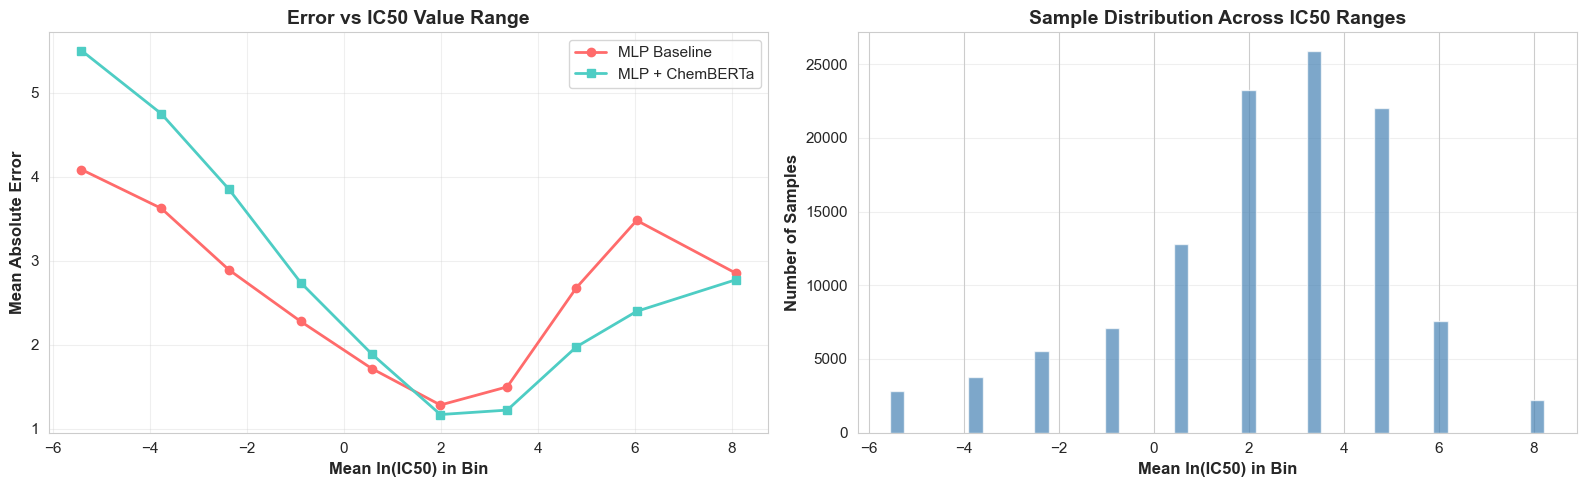


📊 Performance Across IC50 Ranges:
 mean_ic50  error_mlp  error_chemberta  count
 -5.406327   4.086143         5.504160   2856
 -3.761437   3.624055         4.751282   3772
 -2.368116   2.891743         3.852716   5518
 -0.887556   2.276848         2.738902   7126
  0.576587   1.715545         1.889300  12775
  1.990479   1.281410         1.168127  23256
  3.367592   1.497790         1.220848  25858
  4.795166   2.679907         1.975223  22048
  6.035861   3.480410         2.397408   7578
  8.073101   2.853789         2.772509   2190

🔴 Hardest IC50 range: -5.41 (Error: 5.5042)

💡 High variance bins have mean error: 3.3975
   Low variance bins have mean error: 2.2566


In [13]:
# Bin IC50 values
df_test['ic50_bin'] = pd.cut(df_test['y_true'], bins=10, labels=False)
df_test['ic50_range'] = pd.cut(df_test['y_true'], bins=10)

# Calculate errors per bin
ic50_errors = df_test.groupby('ic50_bin').agg({
    'error_mlp': 'mean',
    'error_mlp_chemberta': 'mean',
    'y_true': ['mean', 'std', 'count']
}).reset_index()

ic50_errors.columns = ['bin', 'error_mlp', 'error_chemberta', 
                       'mean_ic50', 'std_ic50', 'count']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Error vs IC50 range
axes[0].plot(ic50_errors['mean_ic50'], ic50_errors['error_mlp'], 
             marker='o', label='MLP Baseline', color='#FF6B6B', linewidth=2)
axes[0].plot(ic50_errors['mean_ic50'], ic50_errors['error_chemberta'], 
             marker='s', label='MLP + ChemBERTa', color='#4ECDC4', linewidth=2)
axes[0].set_xlabel('Mean ln(IC50) in Bin', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Mean Absolute Error', fontweight='bold', fontsize=12)
axes[0].set_title('Error vs IC50 Value Range', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Sample distribution
axes[1].bar(ic50_errors['mean_ic50'], ic50_errors['count'], 
            width=0.3, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Mean ln(IC50) in Bin', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontweight='bold', fontsize=12)
axes[1].set_title('Sample Distribution Across IC50 Ranges', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Performance Across IC50 Ranges:")
print(ic50_errors[['mean_ic50', 'error_mlp', 'error_chemberta', 'count']].to_string(index=False))

hardest_bin = ic50_errors.loc[ic50_errors['error_chemberta'].idxmax()]
print(f"\n🔴 Hardest IC50 range: {hardest_bin['mean_ic50']:.2f} (Error: {hardest_bin['error_chemberta']:.4f})")

high_variance_bins = ic50_errors[ic50_errors['std_ic50'] > ic50_errors['std_ic50'].median()]
print(f"\n💡 High variance bins have mean error: {high_variance_bins['error_chemberta'].mean():.4f}")
print(f"   Low variance bins have mean error: {ic50_errors[ic50_errors['std_ic50'] <= ic50_errors['std_ic50'].median()]['error_chemberta'].mean():.4f}")

## 7. Key Insights Summary

Compile actionable insights from error analysis.

In [14]:
print("=" * 90)
print("KEY INSIGHTS FROM ERROR ANALYSIS")
print("=" * 90)

print("\n🎯 MODEL IMPROVEMENTS:")
best_improvement = ((df_test['error_mlp'].mean() - df_test['error_mlp_chemberta'].mean()) / 
                    df_test['error_mlp'].mean() * 100)
print(f"   • ChemBERTa features reduce error by {best_improvement:.1f}% over baseline")
print(f"   • Median error improved from {df_test['error_mlp'].median():.3f} to {df_test['error_mlp_chemberta'].median():.3f}")

print("\n🔴 CHALLENGING CASES:")
hard_drugs_pct = (drug_errors_sorted.head(20)['error_mlp_chemberta'] > 
                  drug_errors_sorted['error_mlp_chemberta'].median()).sum() / 20 * 100
print(f"   • Top 20 hardest drugs account for {hard_drugs_pct:.0f}% above-median error")
print(f"   • Hardest drug: {drug_errors_sorted.iloc[0]['drug_name']}")

if 'tissue' in df_test.columns:
    hardest_tissue = tissue_errors_sorted.iloc[0]
    print(f"   • Most challenging tissue: {hardest_tissue['tissue']} (error: {hardest_tissue['error_mlp_chemberta']:.3f})")

print("\n💡 ACTIONABLE RECOMMENDATIONS:")
print("   1. Focus on improving predictions for high-error drugs")
print("   2. Investigate molecular properties of hard-to-predict compounds")
if 'tissue' in df_test.columns:
    print("   3. Consider tissue-specific model fine-tuning")
print("   4. Explore ensemble methods to reduce outlier errors")
print("   5. Add uncertainty quantification for high-error predictions")

print("\n" + "=" * 90)

KEY INSIGHTS FROM ERROR ANALYSIS

🎯 MODEL IMPROVEMENTS:
   • ChemBERTa features reduce error by 6.1% over baseline
   • Median error improved from 1.762 to 1.592

🔴 CHALLENGING CASES:
   • Top 20 hardest drugs account for 100% above-median error
   • Hardest drug: THR-102
   • Most challenging tissue: digestive_system / biliary_tract (error: 2.116)

💡 ACTIONABLE RECOMMENDATIONS:
   1. Focus on improving predictions for high-error drugs
   2. Investigate molecular properties of hard-to-predict compounds
   3. Consider tissue-specific model fine-tuning
   4. Explore ensemble methods to reduce outlier errors
   5. Add uncertainty quantification for high-error predictions



## 8. Drug-Tissue Error Heatmap

2D visualization of prediction errors across drug-tissue combinations.

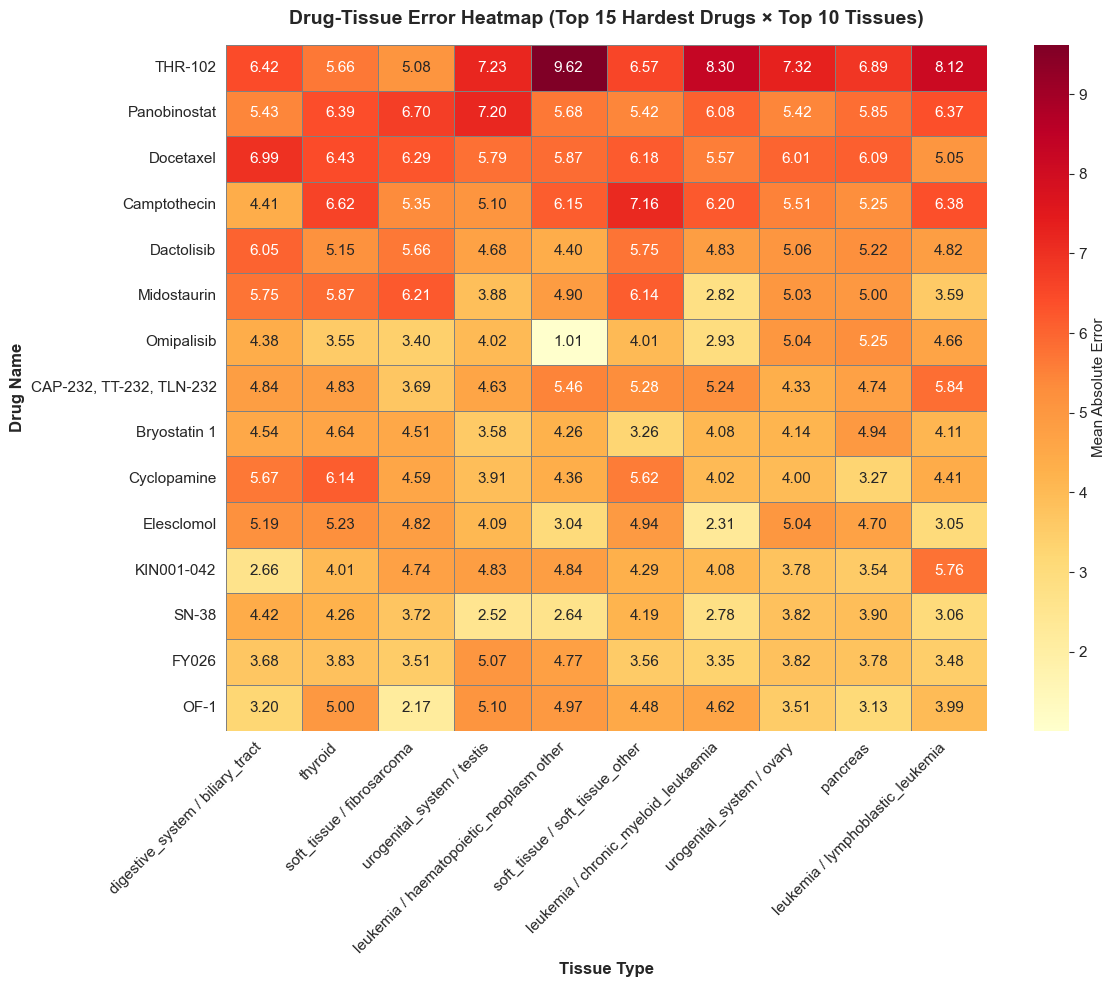


💡 Interpretation:
   • Red cells: Difficult drug-tissue combinations (high error)
   • Light cells: Easier predictions (low error)
   • White cells: No data for this combination
   • Hardest combination: ('THR-102', 'leukemia / haematopoietic_neoplasm other') (Error: 9.62)


In [15]:
# Create drug-tissue error matrix
errors = np.abs(pred_mlp_chemberta - y_true)

# Group by drug and tissue
df_test['error'] = errors
error_matrix = df_test.groupby(['drug_name', 'tissue'])['error'].mean().unstack(fill_value=np.nan)

# Select top drugs and tissues for visualization
top_drugs = df_test.groupby('drug_name')['error'].mean().nlargest(15).index
top_tissues = df_test.groupby('tissue')['error'].mean().nlargest(10).index

error_matrix_subset = error_matrix.loc[top_drugs, top_tissues]

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    error_matrix_subset,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Mean Absolute Error'},
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Drug-Tissue Error Heatmap (Top 15 Hardest Drugs × Top 10 Tissues)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tissue Type', fontsize=12, fontweight='bold')
plt.ylabel('Drug Name', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   • Red cells: Difficult drug-tissue combinations (high error)")
print("   • Light cells: Easier predictions (low error)")
print("   • White cells: No data for this combination")
print(f"   • Hardest combination: {error_matrix.stack().idxmax()} (Error: {error_matrix.stack().max():.2f})")

## 9. Error Distribution Heatmap by IC50 Range and Tissue

Visualize error patterns across different response ranges and tissues.

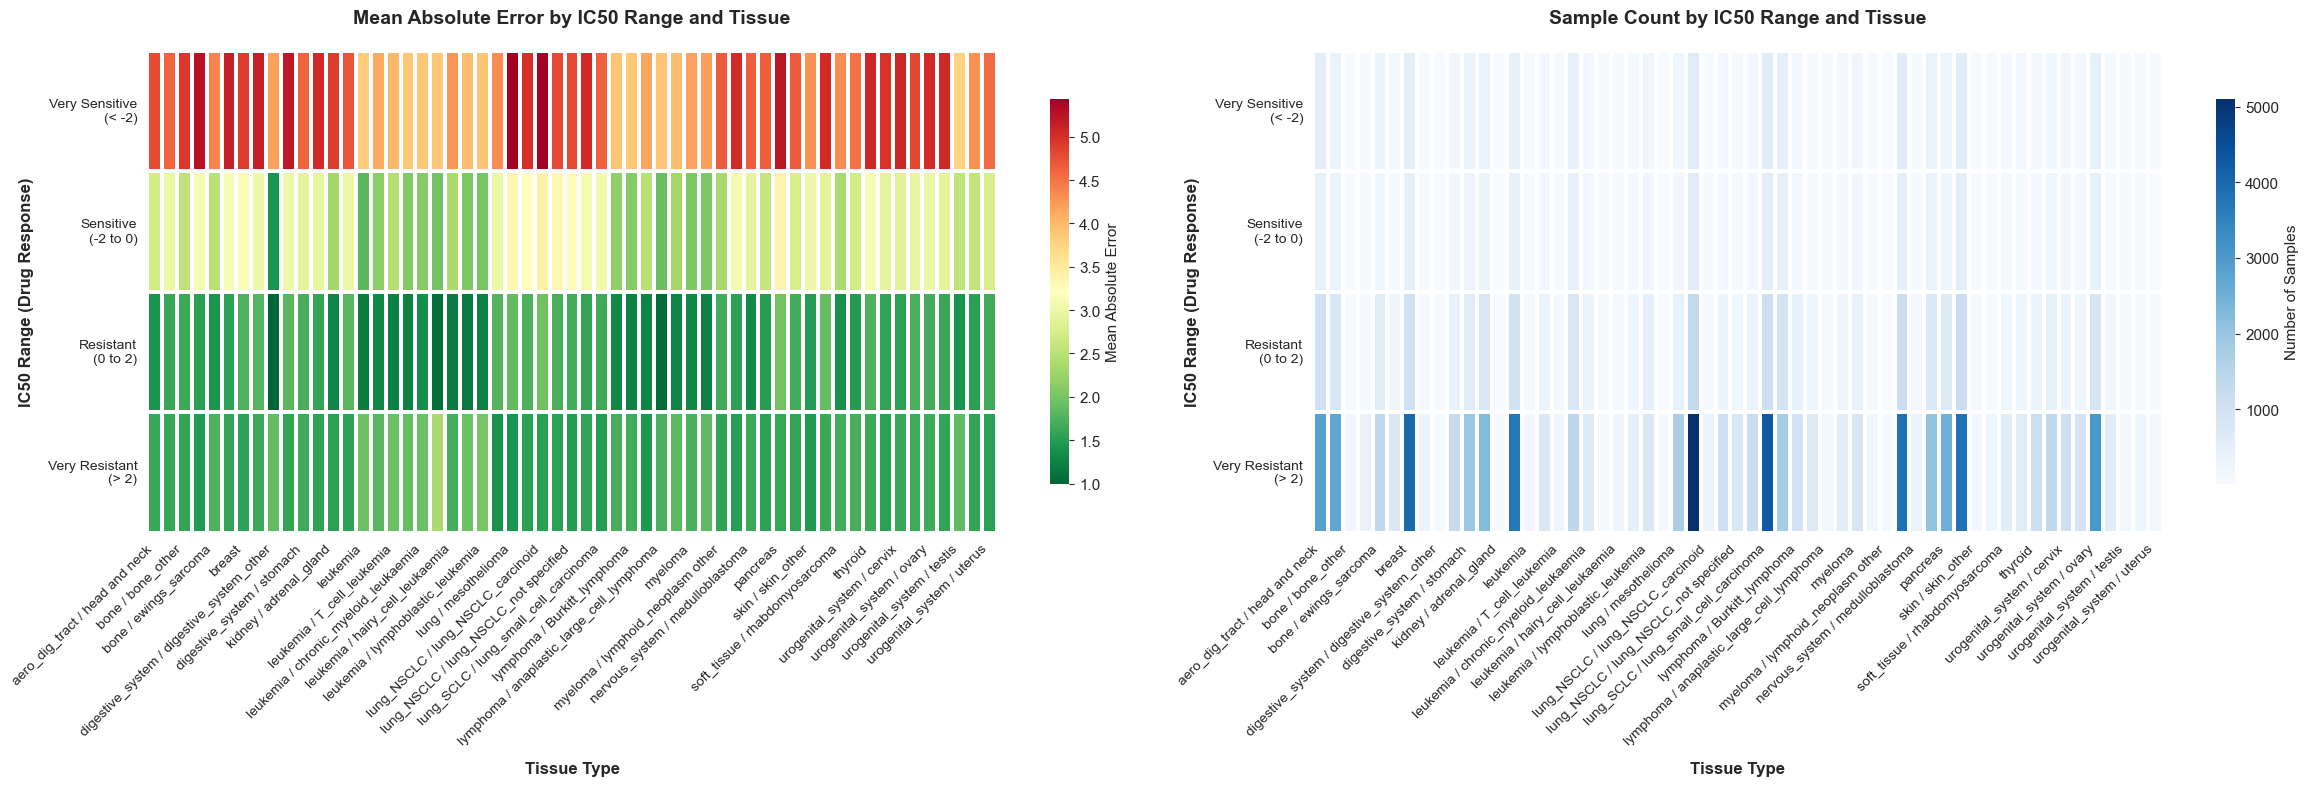


💡 Interpretation:
   • Left heatmap: Error magnitude (red=high error, green=low error)
   • Right heatmap: Sample distribution (dark blue=many samples)
   • Compare to identify if high errors are due to data scarcity or inherent difficulty


In [19]:
# Bin IC50 values into ranges
df_test['IC50_range'] = pd.cut(
    y_true, 
    bins=[-np.inf, -2, 0, 2, np.inf],
    labels=['Very Sensitive\n(< -2)', 'Sensitive\n(-2 to 0)', 'Resistant\n(0 to 2)', 'Very Resistant\n(> 2)']
)

# Create error matrix by IC50 range and tissue
error_by_range_tissue = df_test.groupby(['IC50_range', 'tissue'])['error'].agg(['mean', 'count']).reset_index()
error_pivot = error_by_range_tissue.pivot(index='IC50_range', columns='tissue', values='mean')
count_pivot = error_by_range_tissue.pivot(index='IC50_range', columns='tissue', values='count')

# Create figure with two subplots - LARGER size for better readability
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Heatmap 1: Mean error
sns.heatmap(
    error_pivot,
    cmap='RdYlGn_r',
    annot=False,
    cbar_kws={'label': 'Mean Absolute Error', 'shrink': 0.8},
    ax=axes[0],
    vmin=error_pivot.min().min(),
    vmax=error_pivot.max().max(),
    linewidths=1.5,  # Thicker lines between cells
    linecolor='white'
)
axes[0].set_title('Mean Absolute Error by IC50 Range and Tissue', fontsize=14, fontweight='bold', pad=20)
axes[0].set_xlabel('Tissue Type', fontsize=12, fontweight='bold', labelpad=10)
axes[0].set_ylabel('IC50 Range (Drug Response)', fontsize=12, fontweight='bold', labelpad=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=10)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=10)

# Heatmap 2: Sample counts
sns.heatmap(
    count_pivot,
    cmap='Blues',
    annot=False,
    cbar_kws={'label': 'Number of Samples', 'shrink': 0.8},
    ax=axes[1],
    linewidths=1.5,  # Thicker lines between cells
    linecolor='white'
)
axes[1].set_title('Sample Count by IC50 Range and Tissue', fontsize=14, fontweight='bold', pad=20)
axes[1].set_xlabel('Tissue Type', fontsize=12, fontweight='bold', labelpad=10)
axes[1].set_ylabel('IC50 Range (Drug Response)', fontsize=12, fontweight='bold', labelpad=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=10)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   • Left heatmap: Error magnitude (red=high error, green=low error)")
print("   • Right heatmap: Sample distribution (dark blue=many samples)")
print("   • Compare to identify if high errors are due to data scarcity or inherent difficulty")

## 10. Violin Plots - Error Distribution by Tissue

Show full distribution shape (better than boxplots).

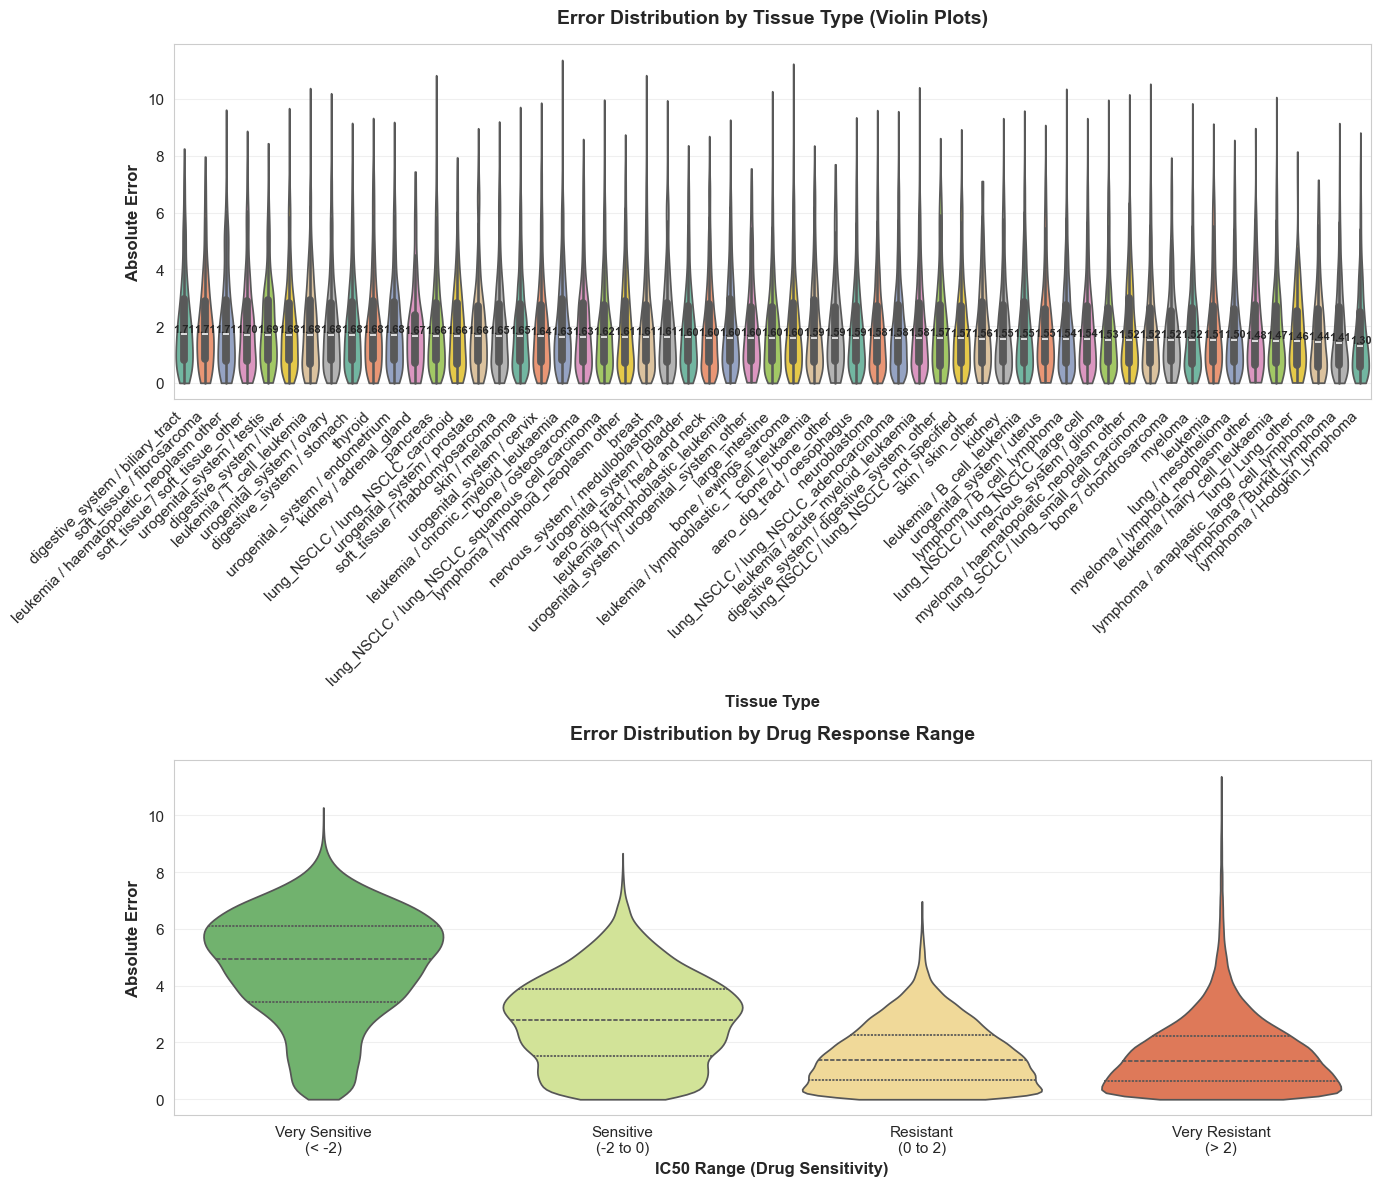


💡 Interpretation:
   • Width shows distribution density (wider = more samples)
   • Inner box shows quartiles and median
   • Shape reveals distribution patterns (bimodal, skewed, etc.)
   • Most variable tissue: digestive_system / biliary_tract (widest distribution)


In [20]:
# Violin plots for error distribution
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Violin plot 1: By tissue
tissue_order = df_test.groupby('tissue')['error'].median().sort_values(ascending=False).index
sns.violinplot(
    data=df_test,
    x='tissue',
    y='error',
    order=tissue_order,
    palette='Set2',
    ax=axes[0],
    inner='box',
    cut=0
)
axes[0].set_title('Error Distribution by Tissue Type (Violin Plots)', 
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Tissue Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Absolute Error', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Add median values
for i, tissue in enumerate(tissue_order):
    median_val = df_test[df_test['tissue'] == tissue]['error'].median()
    axes[0].text(i, median_val + 0.1, f'{median_val:.2f}', 
                ha='center', fontsize=8, fontweight='bold')

# Violin plot 2: By IC50 range
sns.violinplot(
    data=df_test,
    x='IC50_range',
    y='error',
    palette='RdYlGn_r',
    ax=axes[1],
    inner='quartile',
    cut=0
)
axes[1].set_title('Error Distribution by Drug Response Range', 
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('IC50 Range (Drug Sensitivity)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Absolute Error', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   • Width shows distribution density (wider = more samples)")
print("   • Inner box shows quartiles and median")
print("   • Shape reveals distribution patterns (bimodal, skewed, etc.)")
print(f"   • Most variable tissue: {tissue_order[0]} (widest distribution)")

## 11. Hierarchical Clustering - Drug Error Patterns

Dendrogram showing which drugs have similar error profiles.


🔍 Sample of drug names selected for clustering:
['THR-102', 'Gemcitabine', 'Navitoclax', 'Midostaurin', 'Elesclomol', 'Omipalisib', 'Cyclopamine', 'N-acetyl cysteine', 'CAP-232, TT-232, TLN-232', 'TL-1-85']

Total drugs: 50
Unique drugs: 50


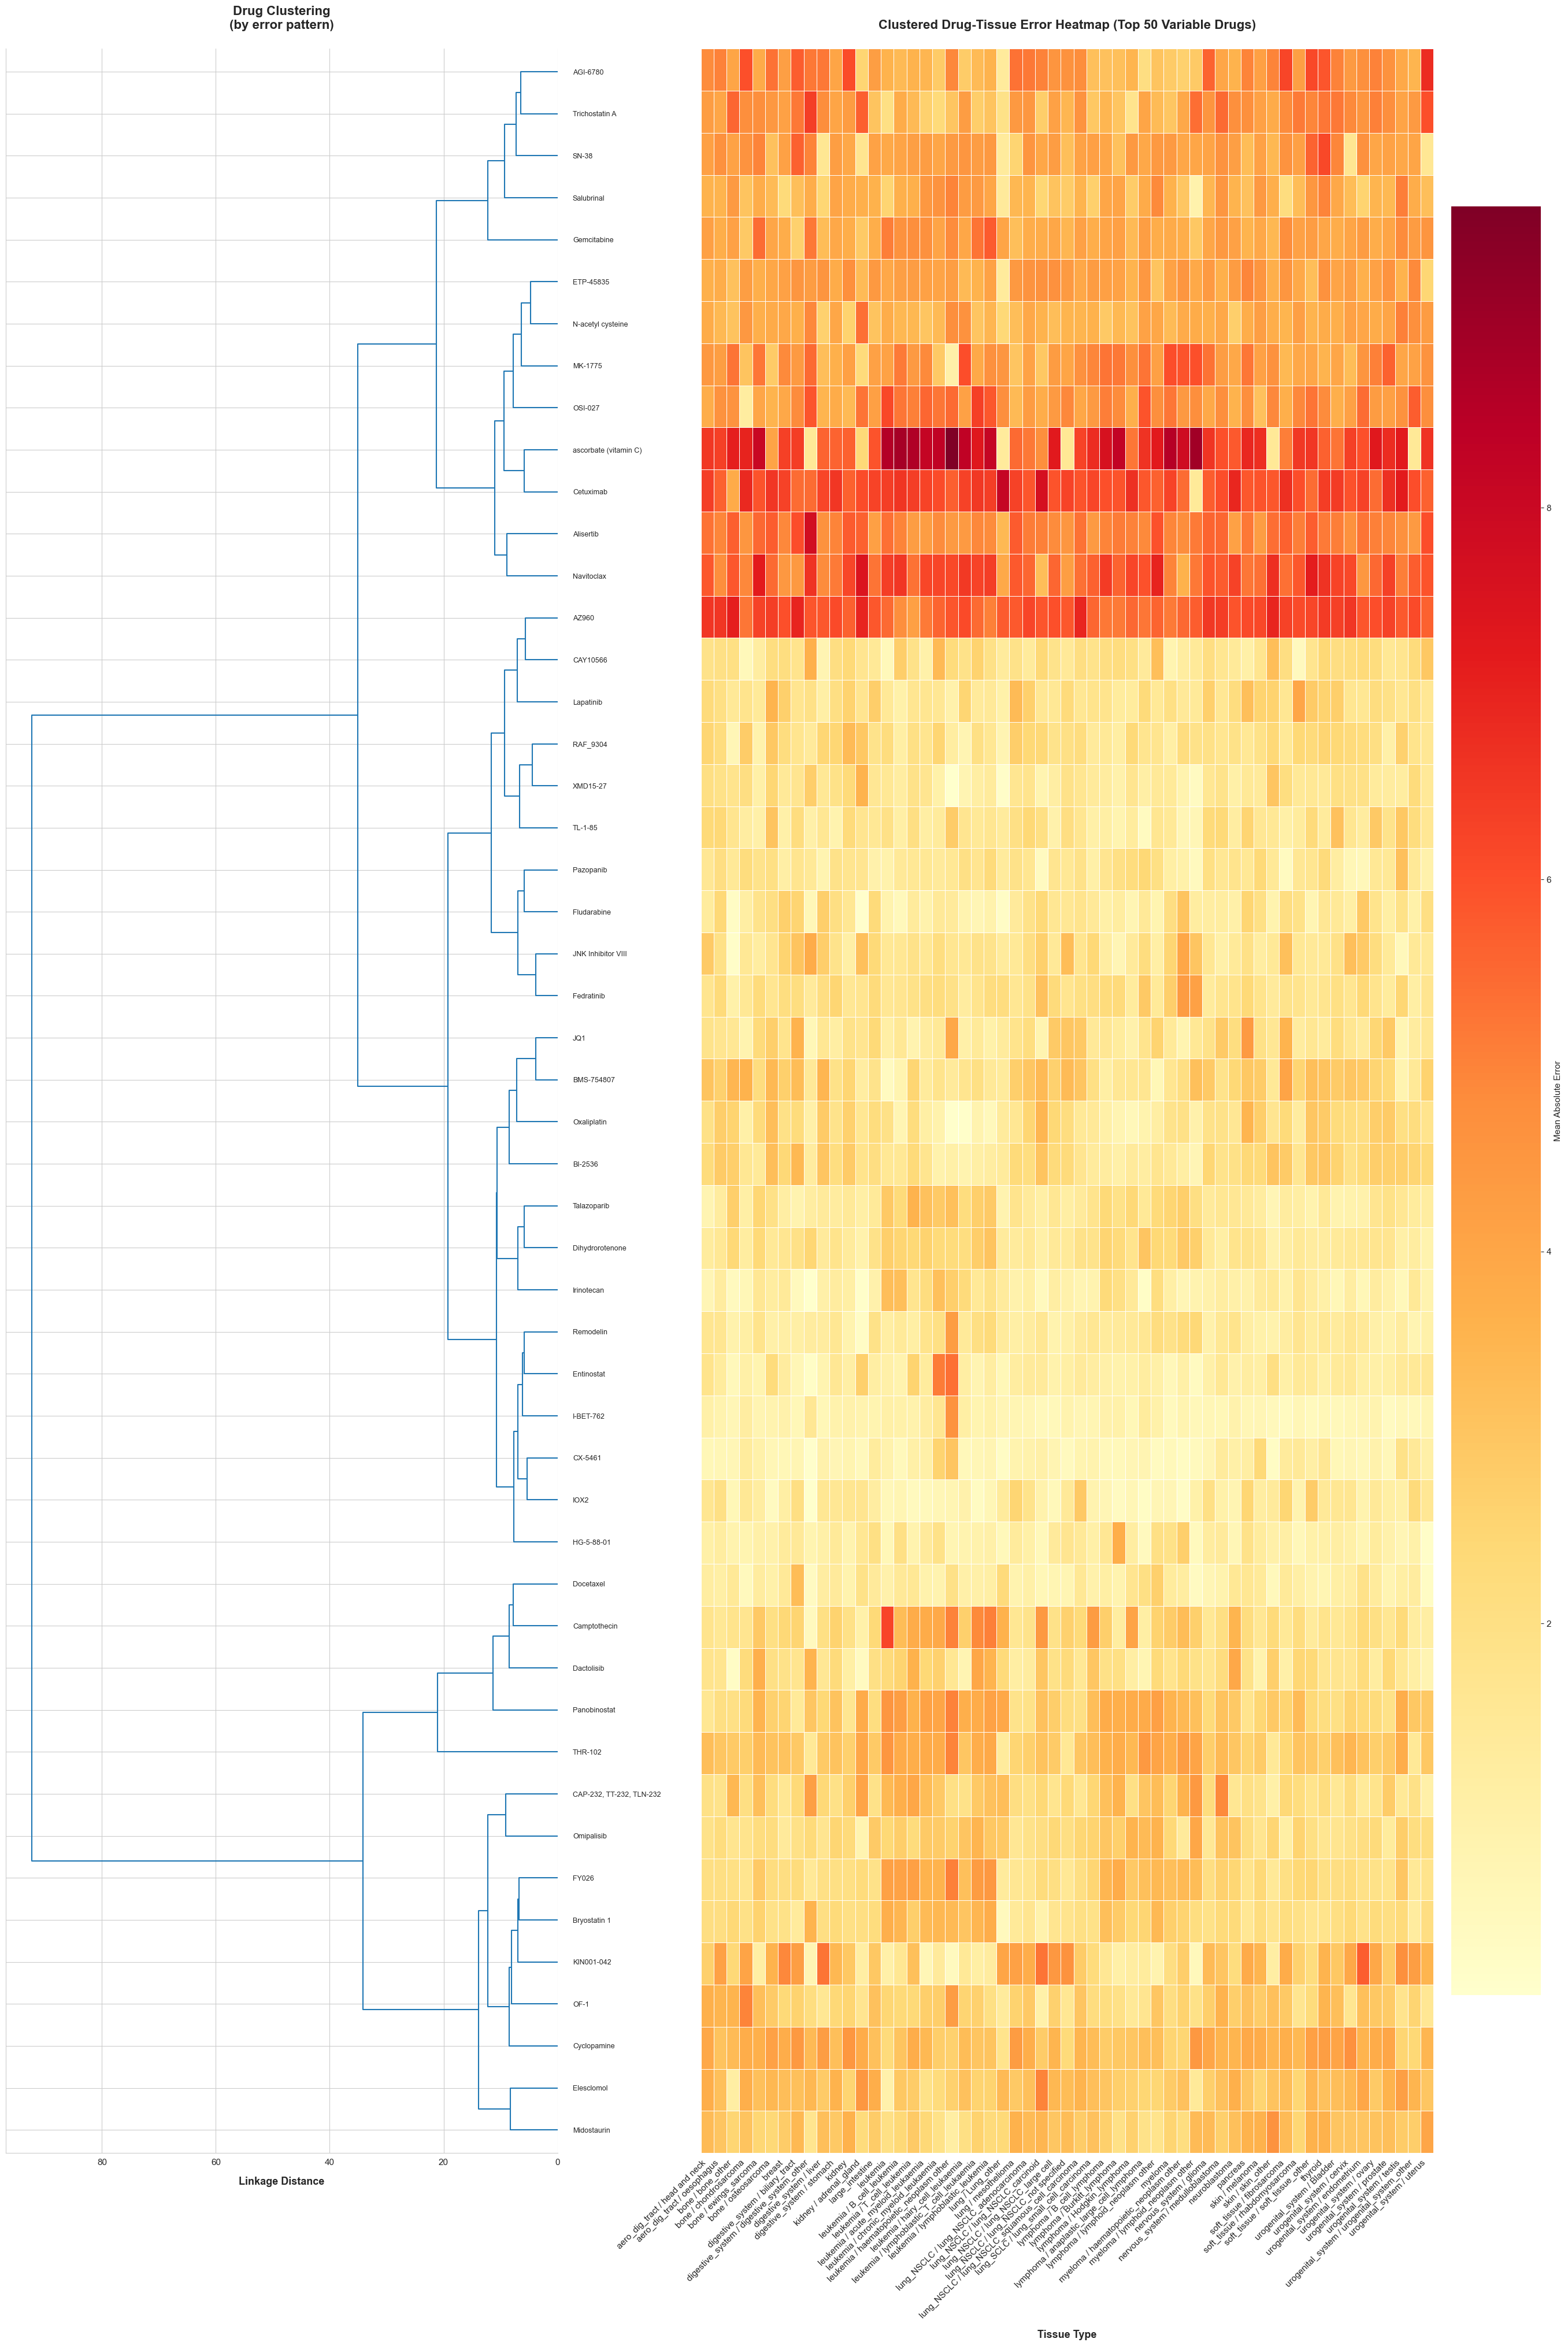


💡 Interpretation:
   • Left: Dendrogram groups drugs with similar error patterns
   • Right: Heatmap ordered by clustering
   • Vertical blocks indicate drug groups with consistent behavior
   • Showing top 50 most variable drugs (out of 121 total)
   • Analyzed across 57 tissue types


In [ ]:
# Hierarchical clustering of drugs by error patterns across tissues
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Create drug-tissue error matrix
drug_tissue_error = df_test.pivot_table(
    values='error',
    index='drug_name',
    columns='tissue',
    aggfunc='mean',
    fill_value=np.nan
)

# Remove drugs with too many missing values & select top 50 most variable drugs for cleaner viz
min_tissues = 3
drug_tissue_error_clean = drug_tissue_error.dropna(thresh=min_tissues)

# Fill remaining NaNs with median
drug_tissue_error_filled = drug_tissue_error_clean.fillna(drug_tissue_error_clean.median())

# Select top 50 drugs with highest error variance across tissues (most interesting patterns)
error_variance = drug_tissue_error_filled.var(axis=1)
top_drugs = error_variance.nlargest(50).index
drug_tissue_error_subset = drug_tissue_error_filled.loc[top_drugs]

# CHECK: Print first 10 drug names to verify uniqueness
print("\n🔍 Sample of drug names selected for clustering:")
print(drug_tissue_error_subset.index.tolist()[:10])
print(f"\nTotal drugs: {len(drug_tissue_error_subset)}")
print(f"Unique drugs: {drug_tissue_error_subset.index.nunique()}")

# Compute linkage on subset
linkage_matrix = linkage(drug_tissue_error_subset, method='ward')

# Create figure with dendrogram and heatmap - EXPLICIT CONTROL over spacing
fig = plt.figure(figsize=(35, 0.8 * 50))  # 0.8 inch per drug row for proper spacing
gs = fig.add_gridspec(1, 2, width_ratios=[2.5, 4], wspace=0.2)

# Dendrogram - with EXPLICIT Y-AXIS CONTROL
ax_dend = fig.add_subplot(gs[0])
dend = dendrogram(
    linkage_matrix,
    orientation='left',
    labels=drug_tissue_error_subset.index.tolist(),
    ax=ax_dend,
    color_threshold=0,
    no_labels=False,
    leaf_font_size=9  # Slightly smaller but clear font
)
ax_dend.set_title('Drug Clustering\n(by error pattern)', 
                  fontsize=16, fontweight='bold', pad=25)
ax_dend.set_xlabel('Linkage Distance', fontsize=13, fontweight='bold', labelpad=12)
# CRITICAL FIX: Force exact y-axis positioning to prevent overlap
ax_dend.set_ylim(-0.5, 50 * 10 + 0.5)  # Explicit y-range with proper spacing
ax_dend.tick_params(axis='y', labelsize=9, pad=15, length=4)  # Extra padding
ax_dend.spines['top'].set_visible(False)
ax_dend.spines['right'].set_visible(False)
# Ensure labels don't get cut off on the right
ax_dend.set_xlim(right=ax_dend.get_xlim()[1] * 1.15)

# Reorder heatmap based on clustering
order = dend['leaves']
drug_tissue_error_ordered = drug_tissue_error_subset.iloc[order]

# Heatmap - with drug name labels on the right
ax_heat = fig.add_subplot(gs[1])
im = sns.heatmap(
    drug_tissue_error_ordered,
    cmap='YlOrRd',
    cbar_kws={'label': 'Mean Absolute Error', 'shrink': 0.85, 'pad': 0.02},
    ax=ax_heat,
    yticklabels=True,  # Show drug names on heatmap side too
    linewidths=0.5,
    linecolor='white'
)
ax_heat.set_title('Clustered Drug-Tissue Error Heatmap (Top 50 Variable Drugs)', 
                  fontsize=16, fontweight='bold', pad=25)
ax_heat.set_xlabel('Tissue Type', fontsize=13, fontweight='bold', labelpad=12)
ax_heat.set_ylabel('')
ax_heat.set_xticklabels(ax_heat.get_xticklabels(), rotation=45, ha='right', fontsize=11)

# Adjust layout with MORE left margin for drug names
plt.subplots_adjust(left=0.20, right=0.98, top=0.97, bottom=0.06)
plt.show()

print("\n💡 Interpretation:")
print("   • Left: Dendrogram groups drugs with similar error patterns")
print("   • Right: Heatmap ordered by clustering")
print("   • Vertical blocks indicate drug groups with consistent behavior")
print(f"   • Showing top 50 most variable drugs (out of {len(drug_tissue_error_filled)} total)")
print(f"   • Analyzed across {len(drug_tissue_error_subset.columns)} tissue types")